In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.1, random_state=1):
        rng = np.random.default_rng(random_state)
        self.weights = rng.normal(0, 0.1, n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.update_log = []  # list of dicts: update, epoch, sample_idx, weights, bias

    @staticmethod
    def step(z):
        return 1 if z >= 0 else 0

    def predict_one(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.step(z)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

    def fit(self, X, y, max_epochs=20, gate_name=""):
        update_count = 0
        for epoch in range(1, max_epochs + 1):
            errors_this_epoch = 0
            for i, (xi, yi) in enumerate(zip(X, y)):
                y_hat = self.predict_one(xi)
                error = yi - y_hat
                if error != 0:
                    self.weights = self.weights + self.lr * error * xi
                    self.bias = self.bias + self.lr * error
                    update_count += 1
                    errors_this_epoch += 1

                    self.update_log.append({
                        "update": update_count,
                        "epoch": epoch,
                        "sample_idx": i,
                        "sample": xi.copy(),
                        "true_label": yi,
                        "pred_before_update": y_hat,
                        "weights": self.weights.copy(),
                        "bias": self.bias
                    })

                    print(f"[{gate_name}] Update {update_count:2d} "
                          f"(epoch {epoch}, sample {i} = {xi.tolist()}, "
                          f"true={yi}, pred={y_hat}) -> "
                          f"weights = {np.round(self.weights, 4)}, "
                          f"bias = {self.bias:.4f}")

            if errors_this_epoch == 0:
                print(f"[{gate_name}] Converged after epoch {epoch} "
                      f"({update_count} total updates).\n")
                return
        print(f"[{gate_name}] Did NOT converge within {max_epochs} epochs "
              f"({update_count} total updates).\n")

In [ ]:
def plot_boundary_2input(X, y, weights, bias, title):
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    colors = ["red" if label == 0 else "blue" for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=150, edgecolor="k", zorder=3)
    for (x0, x1), label in zip(X, y):
        ax.annotate(str(label), (x0, x1), textcoords="offset points",
                    xytext=(8, 8), fontsize=10)

    xx = np.linspace(-0.5, 1.5, 200)
    if abs(weights[1]) > 1e-8:
        yy = -(weights[0] * xx + bias) / weights[1]
        ax.plot(xx, yy, "k-", linewidth=2)
    elif abs(weights[0]) > 1e-8:
        x_vert = -bias / weights[0]
        ax.axvline(x_vert, color="k", linewidth=2)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_boundary_1input(X, y, weight, bias, title):
    fig, ax = plt.subplots(figsize=(4.2, 2.8))
    colors = ["red" if label == 0 else "blue" for label in y]
    ax.scatter(X[:, 0], np.zeros_like(X[:, 0]), c=colors, s=150,
               edgecolor="k", zorder=3)
    for x0, label in zip(X[:, 0], y):
        ax.annotate(str(label), (x0, 0), textcoords="offset points",
                    xytext=(0, 12), fontsize=10, ha="center")

    if abs(weight) > 1e-8:
        x_boundary = -bias / weight
        ax.axvline(x_boundary, color="k", linewidth=2, label="decision boundary")
        ax.legend(loc="upper center", fontsize=8)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("x1")
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_gate(gate_name, X, y, max_epochs=20):
    print(f"\n{'='*60}\nTraining Perceptron for {gate_name} gate\n{'='*60}")
    n_features = X.shape[1]
    p = Perceptron(n_features=n_features, learning_rate=0.1, random_state=1)
    p.fit(X, y, max_epochs=max_epochs, gate_name=gate_name)

    for entry in p.update_log:
        title = (f"{gate_name} - Update {entry['update']} "
                 f"(epoch {entry['epoch']})\n"
                 f"w={np.round(entry['weights'], 3)}, b={entry['bias']:.3f}")
        if n_features == 2:
            plot_boundary_2input(X, y, entry["weights"], entry["bias"], title)
        else:
            plot_boundary_1input(X, y, entry["weights"][0], entry["bias"], title)

    preds = p.predict(X)
    print(f"[{gate_name}] Final predictions: {preds.tolist()} (true: {y.tolist()})")
    return p


Training Perceptron for AND gate
[AND] Update  1 (epoch 1, sample 0 = [0, 0], true=0, pred=1) -> weights = [0.0346 0.0822], bias = -0.1000
[AND] Converged after epoch 2 (1 total updates).



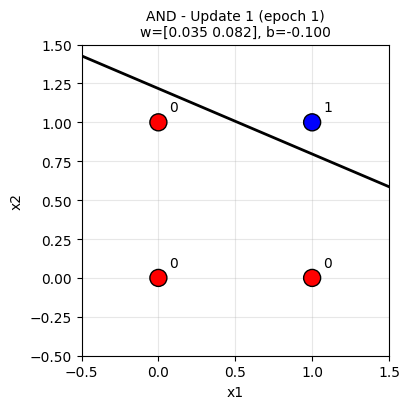

[AND] Final predictions: [0, 0, 0, 1] (true: [0, 0, 0, 1])


In [ ]:
# AND gate
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
p_and = run_gate("AND", X_and, y_and)


Training Perceptron for OR gate
[OR] Update  1 (epoch 1, sample 0 = [0, 0], true=0, pred=1) -> weights = [0.0346 0.0822], bias = -0.1000
[OR] Update  2 (epoch 1, sample 1 = [0, 1], true=1, pred=0) -> weights = [0.0346 0.1822], bias = 0.0000
[OR] Update  3 (epoch 2, sample 0 = [0, 0], true=0, pred=1) -> weights = [0.0346 0.1822], bias = -0.1000
[OR] Update  4 (epoch 2, sample 2 = [1, 0], true=1, pred=0) -> weights = [0.1346 0.1822], bias = 0.0000
[OR] Update  5 (epoch 3, sample 0 = [0, 0], true=0, pred=1) -> weights = [0.1346 0.1822], bias = -0.1000
[OR] Converged after epoch 4 (5 total updates).



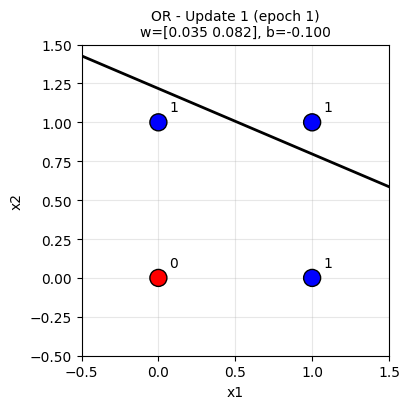

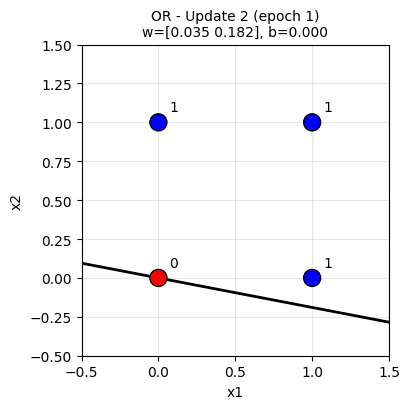

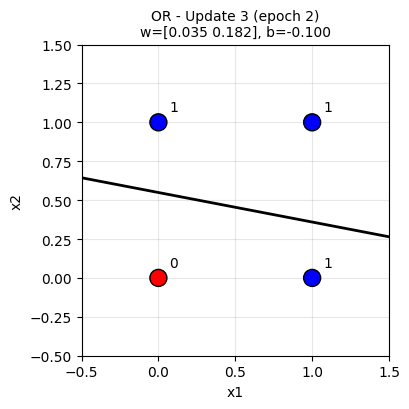

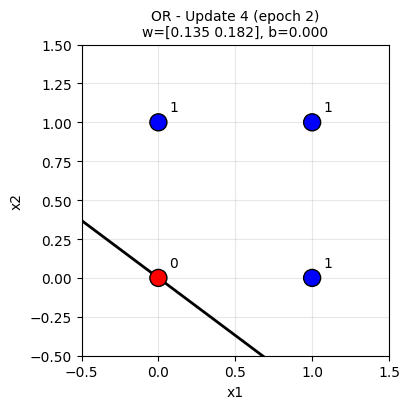

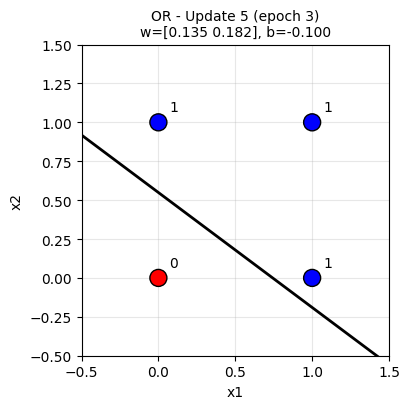

[OR] Final predictions: [0, 1, 1, 1] (true: [0, 1, 1, 1])


In [ ]:
# OR gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])
p_or = run_gate("OR", X_or, y_or)


Training Perceptron for NOT gate
[NOT] Update  1 (epoch 1, sample 1 = [1], true=0, pred=1) -> weights = [-0.0654], bias = -0.1000
[NOT] Update  2 (epoch 2, sample 0 = [0], true=1, pred=0) -> weights = [-0.0654], bias = 0.0000
[NOT] Converged after epoch 3 (2 total updates).



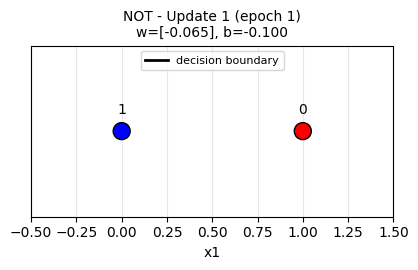

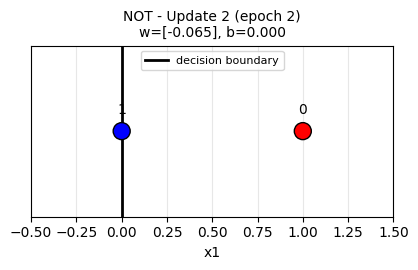

[NOT] Final predictions: [1, 0] (true: [1, 0])


In [ ]:
# NOT gate (single input)
X_not = np.array([[0], [1]])
y_not = np.array([1, 0])
p_not = run_gate("NOT", X_not, y_not)

In [ ]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

MAX_EPOCHS = 30
p_xor = Perceptron(n_features=2, learning_rate=0.1, random_state=1)
p_xor.fit(X_xor, y_xor, max_epochs=MAX_EPOCHS, gate_name="XOR")

[XOR] Update  1 (epoch 1, sample 0 = [0, 0], true=0, pred=1) -> weights = [0.0346 0.0822], bias = -0.1000
[XOR] Update  2 (epoch 1, sample 1 = [0, 1], true=1, pred=0) -> weights = [0.0346 0.1822], bias = 0.0000
[XOR] Update  3 (epoch 1, sample 3 = [1, 1], true=0, pred=1) -> weights = [-0.0654  0.0822], bias = -0.1000
[XOR] Update  4 (epoch 2, sample 1 = [0, 1], true=1, pred=0) -> weights = [-0.0654  0.1822], bias = 0.0000
[XOR] Update  5 (epoch 2, sample 2 = [1, 0], true=1, pred=0) -> weights = [0.0346 0.1822], bias = 0.1000
[XOR] Update  6 (epoch 2, sample 3 = [1, 1], true=0, pred=1) -> weights = [-0.0654  0.0822], bias = 0.0000
[XOR] Update  7 (epoch 3, sample 0 = [0, 0], true=0, pred=1) -> weights = [-0.0654  0.0822], bias = -0.1000
[XOR] Update  8 (epoch 3, sample 1 = [0, 1], true=1, pred=0) -> weights = [-0.0654  0.1822], bias = 0.0000
[XOR] Update  9 (epoch 3, sample 2 = [1, 0], true=1, pred=0) -> weights = [0.0346 0.1822], bias = 0.1000
[XOR] Update 10 (epoch 3, sample 3 = [1, 1

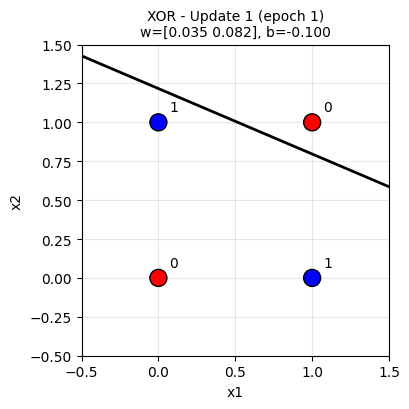

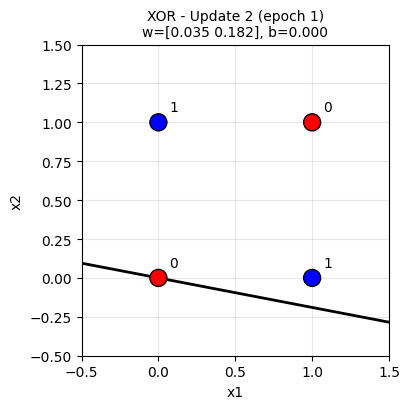

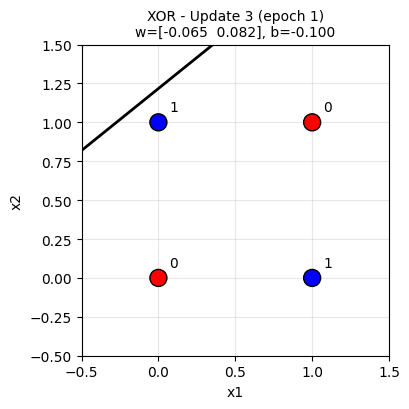

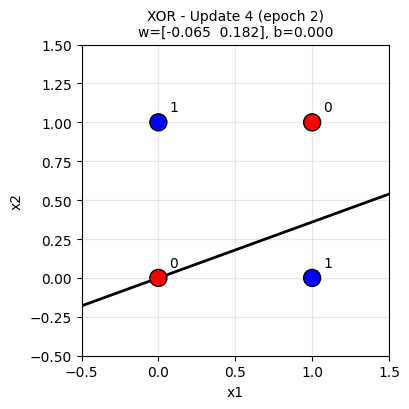

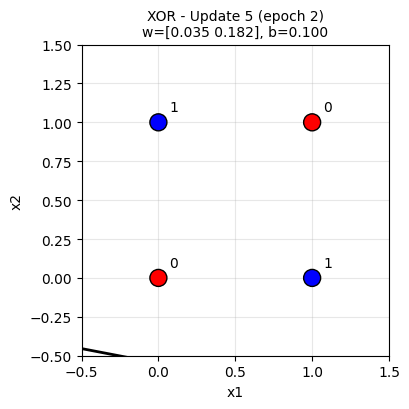

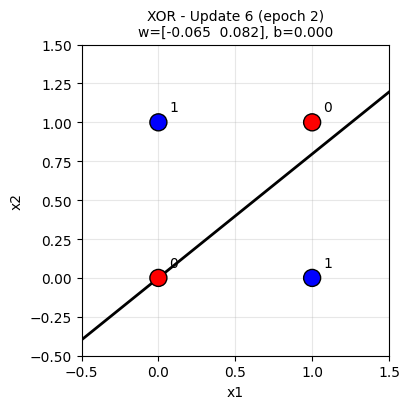

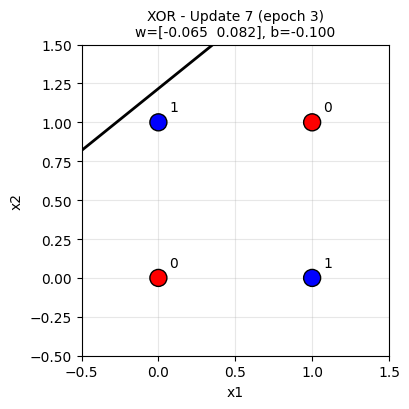

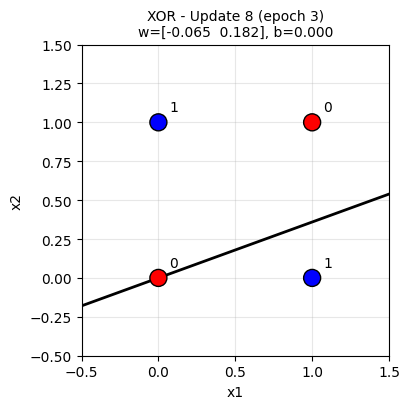

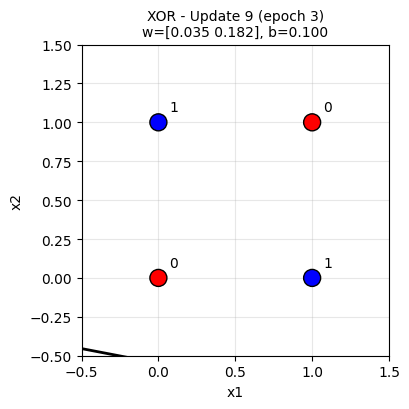

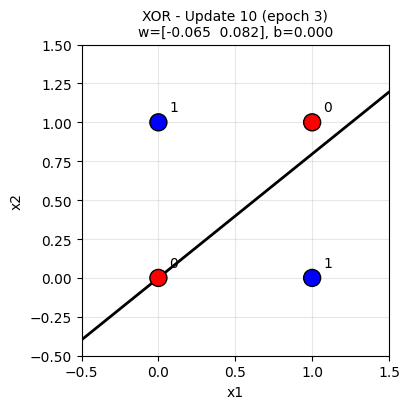

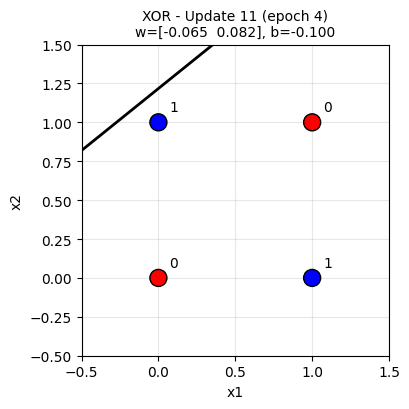

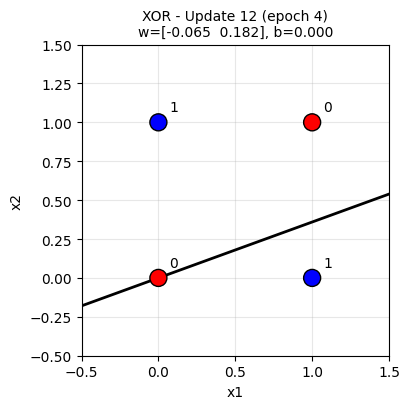

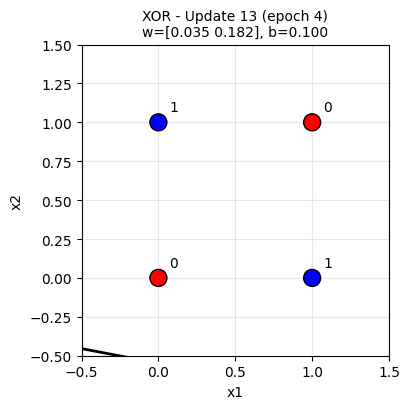

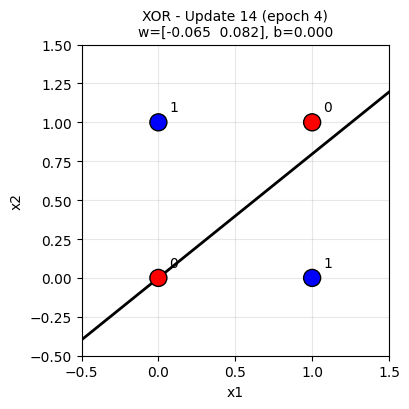

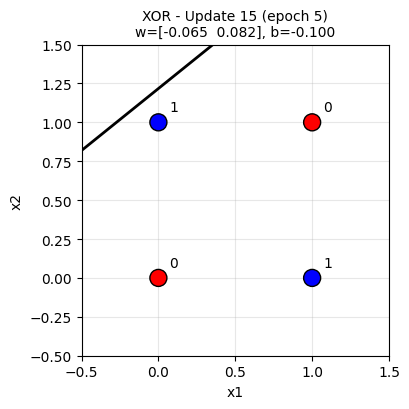

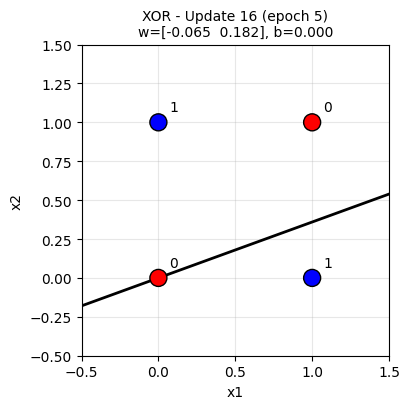

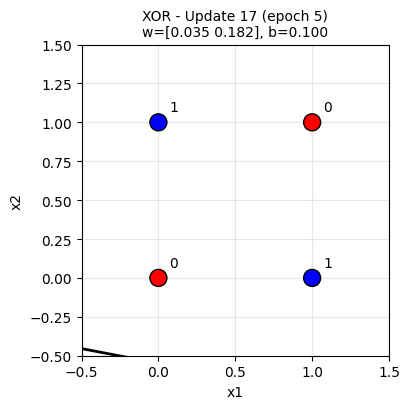

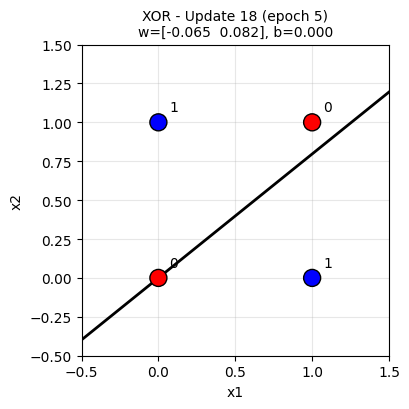

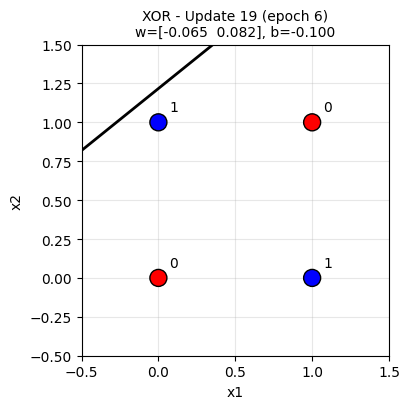

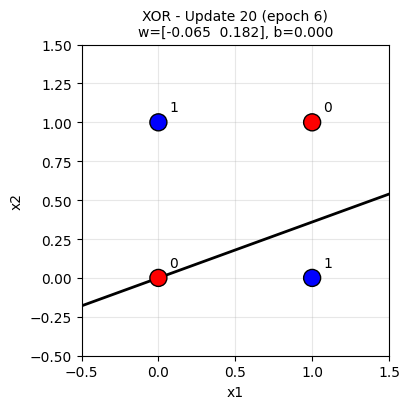

In [ ]:
# Plot decision boundary after each of the first 12 updates
MAX_PLOTTED = 20
for entry in p_xor.update_log[:MAX_PLOTTED]:
    title = (f"XOR - Update {entry['update']} (epoch {entry['epoch']})\n"
             f"w={np.round(entry['weights'], 3)}, b={entry['bias']:.3f}")
    plot_boundary_2input(X_xor, y_xor, entry["weights"], entry["bias"], title)

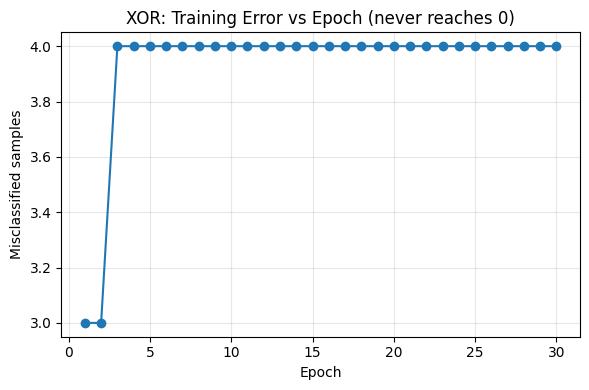

In [ ]:
# Training error vs epoch (never reaches 0)
epochs_range = range(1, MAX_EPOCHS + 1)
errors_per_epoch = [sum(1 for e in p_xor.update_log if e["epoch"] == ep)
                     for ep in epochs_range]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(epochs_range), errors_per_epoch, marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified samples")
ax.set_title("XOR: Training Error vs Epoch (never reaches 0)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
final_preds = p_xor.predict(X_xor)
print(f"Final predictions after {MAX_EPOCHS} epochs: {final_preds.tolist()} (true: {y_xor.tolist()})")

# Detect a repeating (weights, bias) state to prove the perceptron is cycling
seen_states = {}
cycle_found = None
for e in p_xor.update_log:
    state = (tuple(np.round(e["weights"], 4)), round(e["bias"], 4))
    if state in seen_states:
        cycle_found = (seen_states[state], e["update"])
        break
    seen_states[state] = e["update"]

if cycle_found:
    start, repeat = cycle_found
    print(f"\nThe exact (weights, bias) state from update {start} reappears at "
          f"update {repeat} -- the perceptron has entered a repeating cycle of "
          f"weight updates and will loop forever without ever reaching zero error.")
else:
    print("\nNo exact repeated state detected within the epochs run, but the "
          "per-epoch error count oscillates rather than trending to zero, which "
          "is itself evidence of non-convergence.")

print("""
Root cause: XOR is NOT linearly separable. Its four points are
    (0,0) -> 0    (0,1) -> 1    (1,0) -> 1    (1,1) -> 0
No single straight line w1*x1 + w2*x2 + b = 0 can place both class-1
points {(0,1),(1,0)} on one side and both class-0 points {(0,0),(1,1)}
on the other -- the two classes are diagonally interleaved. Since a
single-layer perceptron can only represent a linear decision boundary,
every weight update that fixes one misclassified point necessarily
breaks the classification of another, causing the weights to
oscillate / cycle indefinitely instead of converging. This is exactly
the limitation that motivated the move to Multi-Layer Perceptrons,
which combine multiple linear boundaries through hidden layers to
represent non-linear decision regions like XOR.
""")